# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# Data Splitting

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
dataset_path = "/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/02_data_exploration/cmos_df.csv"
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/03_train_val_test_splitting_plots"
df = pd.read_csv(dataset_path, index_col=0)

In [13]:
## Train, Validation, Test Sets & Scaling (StandardScaler)

First split: 75% training, 25% test
Secound split (train, validation):
33% of 75% ~ 25% of the original data becomes the validation set

Result:
- Train ~50%
- Validation ~25%
- Test 25%

In [14]:
X = df.drop(columns=['tphl', 'tplh', 'energy'])
y = df[['tphl', 'tplh', 'energy']]
print(X.shape)
print(y.shape)

(127771, 7)
(127771, 3)


In [15]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

set_config(transform_output="pandas")

seed = 23

# Test set 25%
Xtr, Xte, ytr, yte = train_test_split(X, y, random_state=seed, test_size=0.25)

# Train/Validation set - train total ~50% and validation ~25%
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, random_state=seed, test_size=0.33)

# The model only knows the train data (fit() only on training data, never on test/validation)
scaler_x = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_sc = scaler_x.transform(X_train)
X_val_sc = scaler_x.transform(X_val)
Xte_sc = scaler_x.transform(Xte)

y_train_sc = scaler_y.transform(y_train)
y_val_sc = scaler_y.transform(y_val)
yte_sc = scaler_y.transform(yte)

print("Train set X", X_train_sc.shape)
print("Train set y", y_train_sc.shape)
print("Validation set X", X_val_sc.shape)
print("Validation set y", y_val_sc.shape)
print("Test set X", Xte_sc.shape)
print("Test set y", yte_sc.shape)

Train set X (64204, 7)
Train set y (64204, 3)
Validation set X (31624, 7)
Validation set y (31624, 3)
Test set X (31943, 7)
Test set y (31943, 3)


In [16]:
X_train.head()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L
59943,0.5031,-0.4734,-25.0,0.7,1.400000e-07,4.200000e-07,3.200000e-08
86477,0.5141,-0.4249,75.0,0.8,7.000000e-08,7.000000e-08,3.200000e-08
58699,0.5281,-0.4640,100.0,0.7,7.000000e-08,3.500000e-07,3.200000e-08
84759,0.5118,-0.4730,-25.0,0.8,7.000000e-08,1.400000e-07,3.200000e-08
53902,0.5026,-0.4438,0.0,0.7,7.000000e-08,3.500000e-07,3.200000e-08


In [17]:
X_train_sc.head()

,PV_nmos,PV_pmos,temperature,voltage,W NMOS,W PMOS,L
59943,-0.395440,-1.466100,-1.377877,-0.461522,2.771445,1.694973,-0.483887
86477,0.266399,1.725939,1.021131,0.470434,-0.360823,-1.214869,-0.483887
58699,1.108739,-0.847437,1.620883,-0.461522,-0.360823,1.113004,-0.483887
84759,0.128014,-1.439774,-1.377877,0.470434,-0.360823,-0.632901,-0.483887
53902,-0.425524,0.482031,-0.778125,-0.461522,-0.360823,1.113004,-0.483887


### Sets Visualization


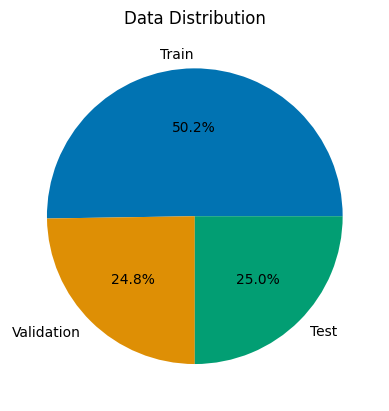

In [18]:
sizes = [len(X_train), len(X_val), len(Xte)]
labels = ['Train', 'Validation', 'Test']

colors = sns.color_palette('colorblind')[0:3]

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Data Distribution')
plt.savefig(f"{plots_dir}/cmos_split_data_distribution.png")
plt.show()
plt.close()

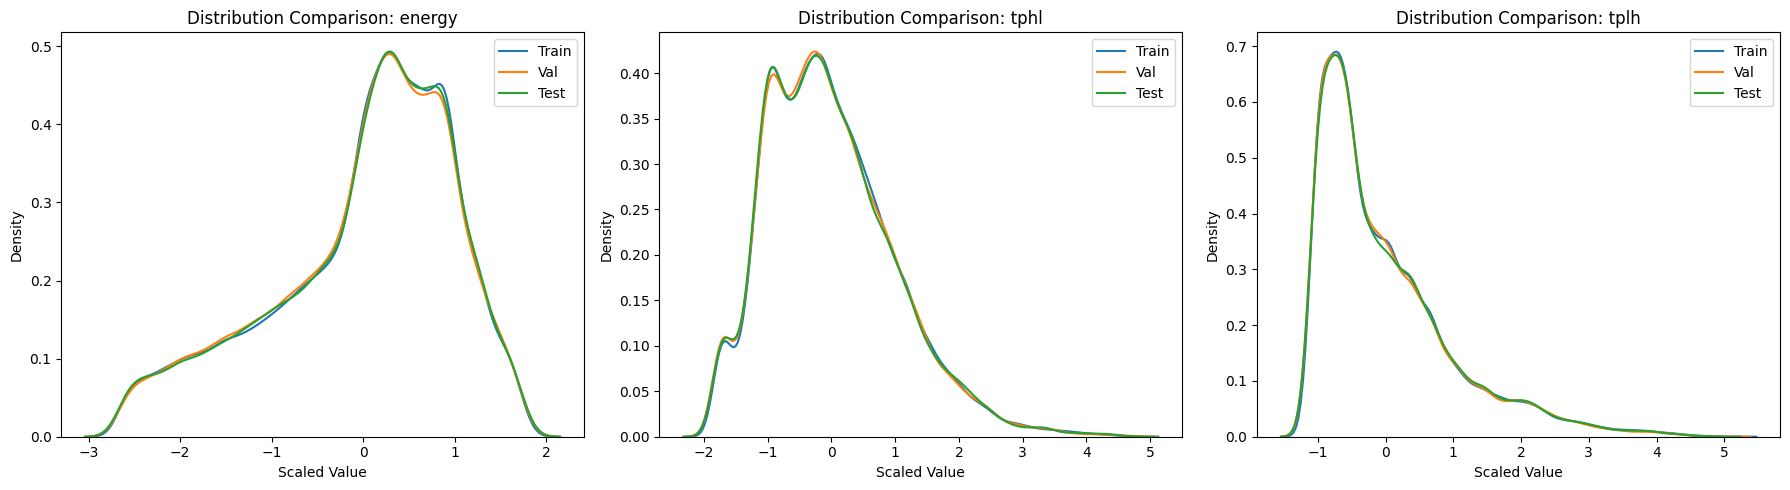

In [19]:
targets = ['energy', 'tphl', 'tplh']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.kdeplot(y_train_sc[col], label='Train', ax=axes[i])
    sns.kdeplot(y_val_sc[col], label='Val', ax=axes[i])
    sns.kdeplot(yte_sc[col], label='Test', ax=axes[i])
    
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{plots_dir}/cmos_dataset_distribution_comparison.png")
plt.show()
plt.close()

In [20]:
# Salvando dados separados e scalers
X_train_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_train_sc.csv', index=False)
X_val_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_val_sc.csv', index=False)
Xte_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_test_sc.csv', index=False)

y_train_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_train_sc.csv', index=False)
y_val_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_val_sc.csv', index=False)
yte_sc.to_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_test_sc.csv', index=False)

import joblib
joblib.dump(scaler_x, '/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_x.pkl')
joblib.dump(scaler_y, '/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_y.pkl')

['/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_y.pkl']